# RNN ile Hisse Senedi Fiyat Tahmini (Netflix)

Bu notebook'ta **Recurrent Neural Network (RNN)** ve **LSTM (Long Short-Term Memory)** modellerini kullanarak Netflix (NFLX) hisse senedi fiyatlarını tahmin edeceğiz.

**Orijinal tutorial**: RNN temellerini sentetik verilerle öğretmekteydi.
**Bu uyarlamada**: Gerçek Netflix hisse verileri kullanılarak RNN'lerin zaman serisi tahminindeki etkinliği göreceğiz.

**Veri kaynağı:** Yahoo Finance API (`yfinance` kütüphanesi) — Kaggle API gerektirmez.

**Konu başlıkları:**
1. Veri çekme ve yükleme
2. Keşifçi Veri Analizi (EDA)
3. Veri hazırlığı ve sekans oluşturma
4. Vanilla RNN modeli ile tahmin
5. LSTM modeli ile tahmin
6. Modellerin karşılaştırılması
7. Vanishing Gradient problemi gösterimi
8. Sonuçlar ve değerlendirmeler

## 0. Gerekli Kütüphaneler

In [1]:
!pip install yfinance matplotlib seaborn scikit-learn pandas numpy torch -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import yfinance as yf
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cpu


## 1. Veri Setini Çekme

`yfinance` kütüphanesi ile Yahoo Finance'tan doğrudan Netflix (NFLX) hisse senedi verilerini çekiyoruz.

> **Avantaj:** Kaggle API anahtarı gerektirmez, herhangi bir Colab ortamında çalışır.

In [3]:
# Netflix hisse senedi verilerini çek (2018-2024)
ticker = yf.Ticker("NFLX")
df = ticker.history(start="2018-01-01", end="2024-01-01")

# Gereksiz sütunları kaldır
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.index = pd.to_datetime(df.index)
df.index = df.index.tz_localize(None)  # timezone bilgisini kaldır

print(f"Veri seti boyutu: {df.shape}")
print(f"Tarih aralığı: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Toplam {len(df)} iş günü")
df.head(10)

Veri seti boyutu: (1509, 5)
Tarih aralığı: 2018-01-02 → 2023-12-29
Toplam 1509 iş günü


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,19.610001,20.165001,19.542000,20.107000,109669000
2018-01-03,20.205000,20.621000,20.150000,20.504999,85914000
2018-01-04,20.620001,20.705000,20.400000,20.563000,60296000
2018-01-05,20.725000,21.002001,20.559000,20.999001,70332000
2018-01-08,21.002001,21.250000,20.844000,21.205000,55802000
2018-01-09,21.211000,21.298000,20.858999,20.931000,61259000
2018-01-10,20.757000,21.364000,20.691000,21.252001,59515000
2018-01-11,21.429001,21.775000,21.334999,21.724001,76595000
2018-01-12,21.718000,22.254999,21.600000,22.122999,81994000


## 2. Keşifçi Veri Analizi (EDA)

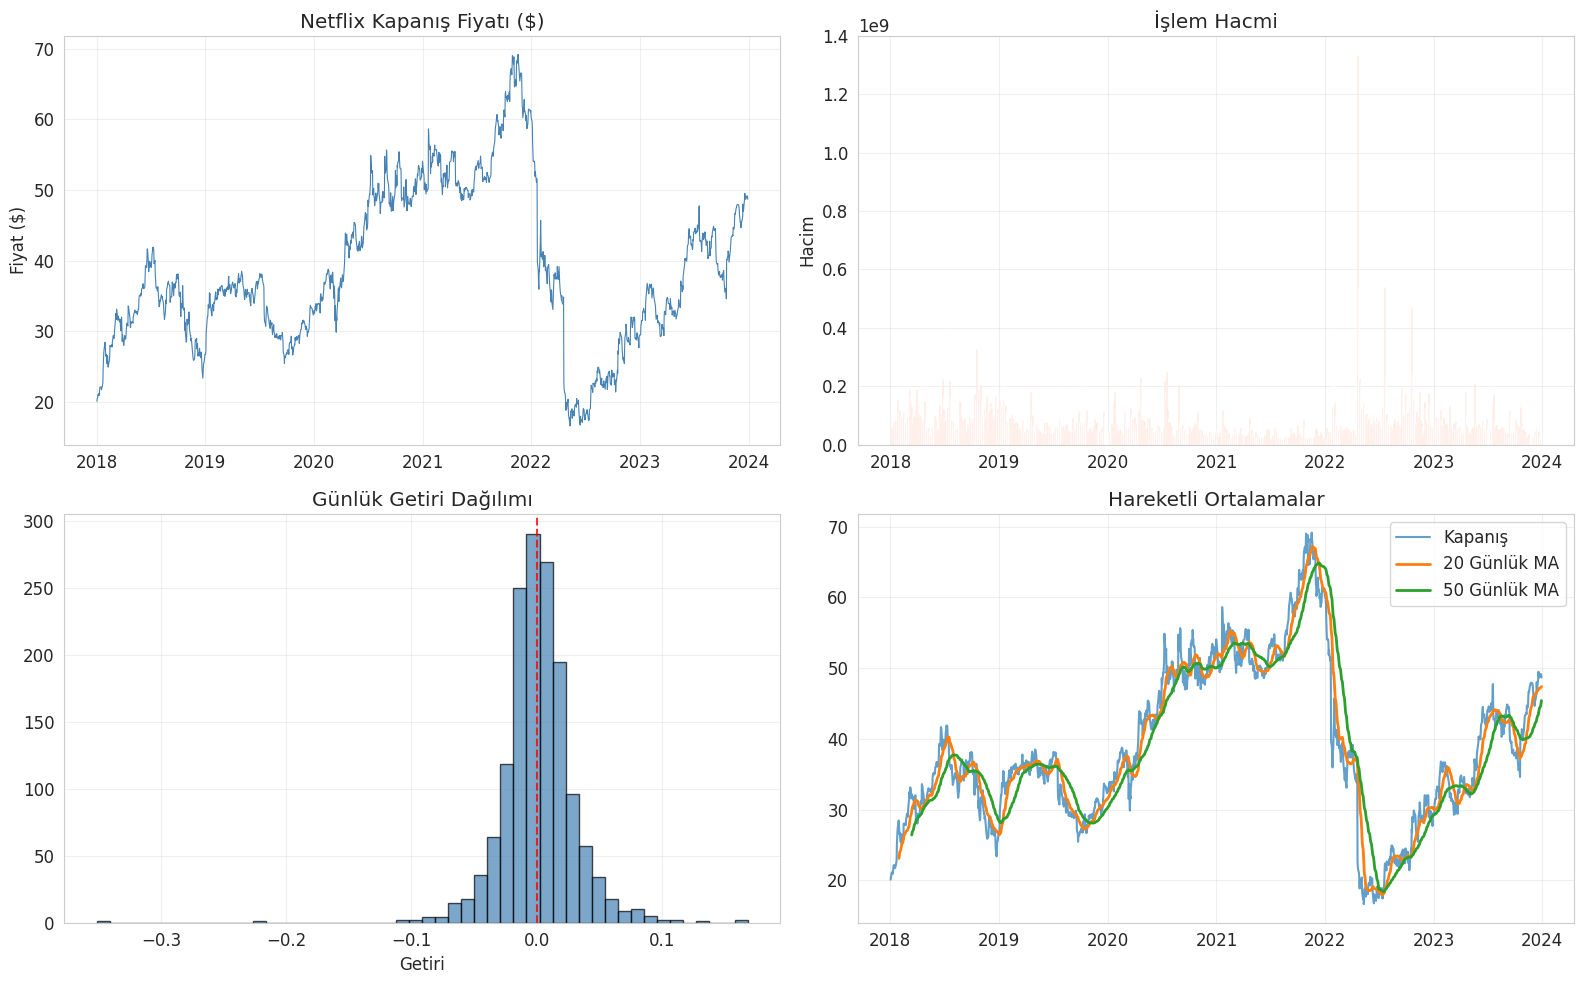


İstatistikler:
  Ortalama fiyat: $38.82
  Std sapma:      $11.13
  Min fiyat:      $16.64
  Max fiyat:      $69.17


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Kapanış fiyatı
axes[0, 0].plot(df.index, df['Close'], color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Netflix Kapanış Fiyatı ($)')
axes[0, 0].set_ylabel('Fiyat ($)')
axes[0, 0].grid(True, alpha=0.3)

# İşlem hacmi
axes[0, 1].bar(df.index, df['Volume'], color='coral', alpha=0.6, width=1)
axes[0, 1].set_title('İşlem Hacmi')
axes[0, 1].set_ylabel('Hacim')
axes[0, 1].grid(True, alpha=0.3)

# Günlük getiri dağılımı
daily_returns = df['Close'].pct_change().dropna()
axes[1, 0].hist(daily_returns, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Günlük Getiri Dağılımı')
axes[1, 0].set_xlabel('Getiri')
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.8)
axes[1, 0].grid(True, alpha=0.3)

# Hareketli ortalamalar
axes[1, 1].plot(df.index, df['Close'], label='Kapanış', alpha=0.7)
axes[1, 1].plot(df.index, df['Close'].rolling(20).mean(), label='20 Günlük MA', linewidth=2)
axes[1, 1].plot(df.index, df['Close'].rolling(50).mean(), label='50 Günlük MA', linewidth=2)
axes[1, 1].set_title('Hareketli Ortalamalar')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nİstatistikler:")
print(f"  Ortalama fiyat: ${df['Close'].mean():.2f}")
print(f"  Std sapma:      ${df['Close'].std():.2f}")
print(f"  Min fiyat:      ${df['Close'].min():.2f}")
print(f"  Max fiyat:      ${df['Close'].max():.2f}")

## 3. Veri Hazırlığı

RNN/LSTM modelleri için veriyi以下 şekilde hazırlıyoruz:
1. **MinMaxScaler** ile [0, 1] aralığına normalize et
2. **Sliding window** ile sekanslar oluştur (60 gün → 61. gün)
3. Train / Validation / Test olarak böl

In [5]:
# Kapanış fiyatını kullan
data = df['Close'].values.reshape(-1, 1)

# Normalize et
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Sliding window ile sekans oluştur
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 60  # Son 60 gün → bir sonraki gün
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Bölümlere ayır (temporal split - shuffle yok!)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# PyTorch tensorlerine çevir
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

print(f"Eğitim seti:   {X_train.shape}")
print(f"Doğrulama seti: {X_val.shape}")
print(f"Test seti:      {X_test.shape}")
print(f"Sekans uzunluğu: {SEQ_LENGTH} gün")

Eğitim seti:   (1014, 60, 1)
Doğrulama seti: (217, 60, 1)
Test seti:      (218, 60, 1)
Sekans uzunluğu: 60 gün


## 4. Vanilla RNN Modeli

In [6]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

def train_model(model, X_train, y_train, X_val, y_val, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            val_losses.append(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}")

    model.load_state_dict(best_state)
    return train_losses, val_losses

VANILLA RNN EĞİTİMİ
  Epoch  20/100 | Train Loss: 0.036430 | Val Loss: 0.050621
  Epoch  40/100 | Train Loss: 0.019222 | Val Loss: 0.041369
  Epoch  60/100 | Train Loss: 0.003973 | Val Loss: 0.010407
  Epoch  80/100 | Train Loss: 0.001242 | Val Loss: 0.001979
  Epoch 100/100 | Train Loss: 0.001178 | Val Loss: 0.001541


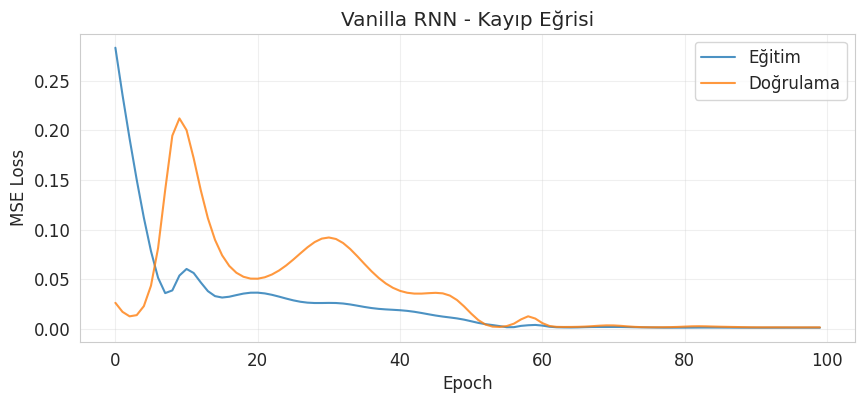

In [7]:
print("=" * 60)
print("VANILLA RNN EĞİTİMİ")
print("=" * 60)

rnn_model = VanillaRNN(input_size=1, hidden_size=64, num_layers=1).to(device)
rnn_train_losses, rnn_val_losses = train_model(
    rnn_model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=100, lr=0.001
)

plt.figure(figsize=(10, 4))
plt.plot(rnn_train_losses, label='Eğitim', alpha=0.8)
plt.plot(rnn_val_losses, label='Doğrulama', alpha=0.8)
plt.title('Vanilla RNN - Kayıp Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. LSTM Modeli

LSTM EĞİTİMİ
  Epoch  20/100 | Train Loss: 0.031984 | Val Loss: 0.085994
  Epoch  40/100 | Train Loss: 0.025974 | Val Loss: 0.091223
  Epoch  60/100 | Train Loss: 0.005510 | Val Loss: 0.017192
  Epoch  80/100 | Train Loss: 0.003098 | Val Loss: 0.013134
  Epoch 100/100 | Train Loss: 0.002615 | Val Loss: 0.008192


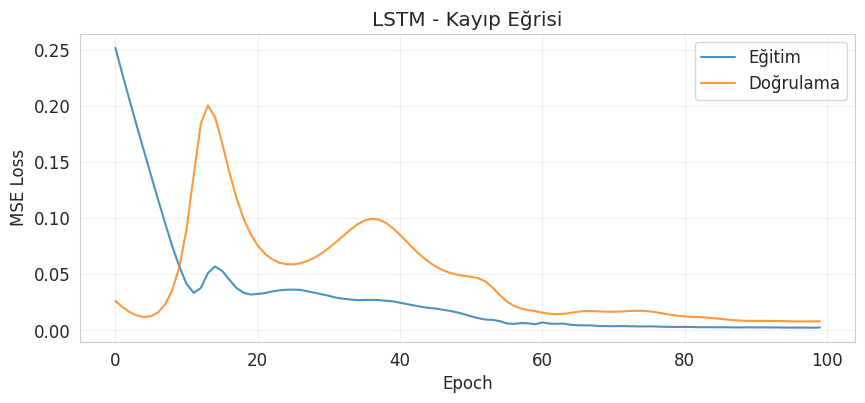

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

print("=" * 60)
print("LSTM EĞİTİMİ")
print("=" * 60)

lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=100, lr=0.001
)

plt.figure(figsize=(10, 4))
plt.plot(lstm_train_losses, label='Eğitim', alpha=0.8)
plt.plot(lstm_val_losses, label='Doğrulama', alpha=0.8)
plt.title('LSTM - Kayıp Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Model Karşılaştırması

      Model  RMSE ($)  MAE ($)  MAPE (%)     R²
Vanilla RNN      1.49     1.20      3.09 0.9269
       LSTM      2.40     2.01      4.99 0.8086


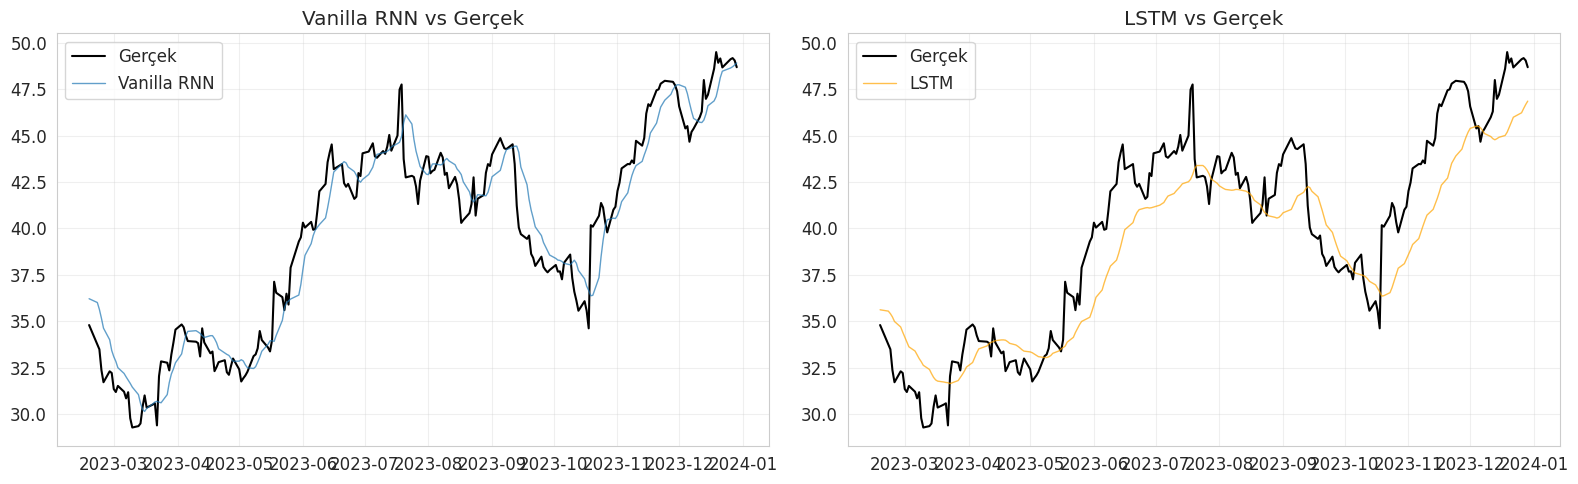

In [9]:
def predict_and_evaluate(model, X_test, y_test, scaler, model_name):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).cpu().numpy()
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.cpu().numpy())
    return predictions, actual

rnn_pred, actual = predict_and_evaluate(rnn_model, X_test_t, y_test_t, scaler, "RNN")
lstm_pred, _ = predict_and_evaluate(lstm_model, X_test_t, y_test_t, scaler, "LSTM")

# Metrikler
def calc_metrics(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': name, 'RMSE ($)': round(rmse, 2), 'MAE ($)': round(mae, 2),
            'MAPE (%)': round(mape, 2), 'R²': round(r2, 4)}

metrics = pd.DataFrame([
    calc_metrics(actual, rnn_pred, 'Vanilla RNN'),
    calc_metrics(actual, lstm_pred, 'LSTM')
])
print(metrics.to_string(index=False))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

test_dates = df.index[-len(actual):]

axes[0].plot(test_dates, actual, label='Gerçek', color='black', linewidth=1.5)
axes[0].plot(test_dates, rnn_pred, label='Vanilla RNN', alpha=0.7, linewidth=1)
axes[0].set_title('Vanilla RNN vs Gerçek')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_dates, actual, label='Gerçek', color='black', linewidth=1.5)
axes[1].plot(test_dates, lstm_pred, label='LSTM', alpha=0.7, linewidth=1, color='orange')
axes[1].set_title('LSTM vs Gerçek')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Vanishing Gradient Gösterimi

RNN ve LSTM arasındaki temel fark, gradyanların zaman adımları boyunca nasıl aktarıldığıdır. RNN'de gradyanlar "kaybolur" (vanish), LSTM'de ise gate mekanizmaları sayesinde korunur.

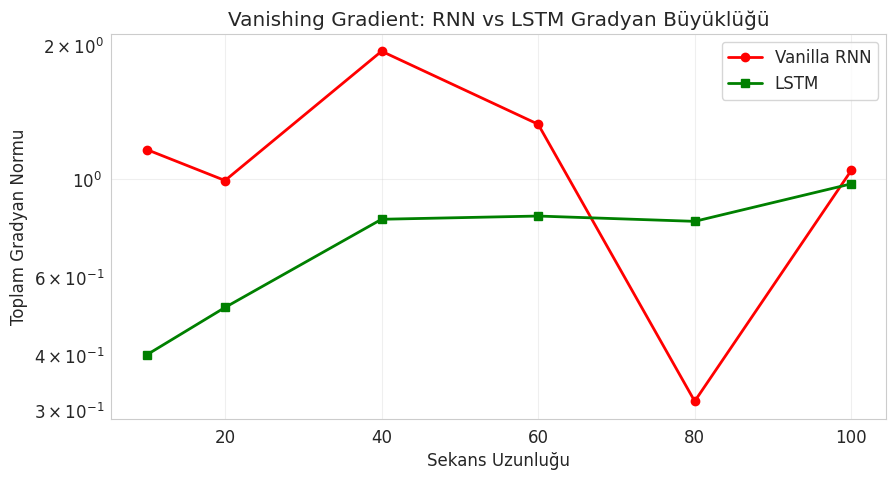

RNN gradyanları sekans uzadıkça küçülür (kaybolur).
LSTM gradyanları door mekanizmaları sayesinde daha kararlı kalır.


In [10]:
def measure_gradient_norm(model, X_sample, y_sample):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    optimizer.zero_grad()
    output = model(X_sample)
    loss = nn.MSELoss()(output, y_sample)
    loss.backward()
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    return total_norm ** 0.5

# Farklı sekans uzunluklarında gradyan normları
seq_lengths = [10, 20, 40, 60, 80, 100]
rnn_norms, lstm_norms = [], []

for sl in seq_lengths:
    if sl < len(X):
        X_sub, y_sub = create_sequences(data_scaled, sl)
        n = min(100, len(X_sub))
        X_t = torch.FloatTensor(X_sub[:n]).to(device)
        y_t = torch.FloatTensor(y_sub[:n]).to(device)

        rnn_temp = VanillaRNN(1, 64, 1).to(device)
        lstm_temp = LSTMModel(1, 64, 2).to(device)

        rnn_norms.append(measure_gradient_norm(rnn_temp, X_t, y_t))
        lstm_norms.append(measure_gradient_norm(lstm_temp, X_t, y_t))
    else:
        rnn_norms.append(float('nan'))
        lstm_norms.append(float('nan'))

plt.figure(figsize=(10, 5))
plt.plot(seq_lengths, rnn_norms, 'o-', label='Vanilla RNN', color='red', linewidth=2)
plt.plot(seq_lengths, lstm_norms, 's-', label='LSTM', color='green', linewidth=2)
plt.xlabel('Sekans Uzunluğu')
plt.ylabel('Toplam Gradyan Normu')
plt.title('Vanishing Gradient: RNN vs LSTM Gradyan Büyüklüğü')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print("RNN gradyanları sekans uzadıkça küçülür (kaybolur).")
print("LSTM gradyanları door mekanizmaları sayesinde daha kararlı kalır.")

## 8. Sonuç

| Konu | Vanilla RNN | LSTM |
|------|-------------|------|
| **Mimari** | Tek gate (hidden state) | 3 gate (forget, input, output) + cell state |
| **Uzun Sekanslar** | Zayıf (vanishing gradient) | Güçlü (gradient koruması) |
| **Eğitim Hızı** | Daha hızlı | Daha yavaş |
| **Genelleme** | Kısa vadeli bağımlılıklar | Uzun vadeli bağımlılıklar |

**Öğrenilen dersler:**
- RNN'ler kısa vadeli bağımlılıkları yakalayabilir ancak uzun vadeli bağımlılıklarda zayıftır
- LSTM'ler gate mekanizmaları sayesinde uzun vadeli bağımlılıkları daha iyi öğrenir
- Hisse senedi tahmininde her iki model de belirli bir doğruluk seviyesine ulaşır ancak piyasalar kaotik olduğundan kesin tahmin imkansızdır
- Gradient clipping, öğrenme oranı zamanlaması ve regularizasyon önemlidir